# Predicting ADHD From Physiological and Phenotypic Data 

KNN 

In [1]:
# Import packages for KNN classification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold

In [2]:
# Import the data 
phenotype = "C:\\Users\halom\BINF_6310\Final Project\hyperaktiv_with_controls\\patient_info.csv"

pat_info_df = pd.read_csv(phenotype, sep=";")

pat_info_df

,ID,SEX,AGE,ACC,ACC_TIME,ACC_DAYS,HRV,HRV_TIME,HRV_HOURS,CPT_II,...,HADS_D,MED,MED_Antidepr,MED_Moodstab,MED_Antipsych,MED_Anxiety_Benzo,MED_Sleep,MED_Analgesics_Opioids,MED_Stimulants,filter_$
0,1,0,3,1,16:00:00,6,1,11:00:00,21.0,0,...,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,2,0,4,1,10:54:00,6.8,0,NaN,NaN,1,...,7.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,3,1,2,1,15:28:00,7.2,1,15:25:00,21.0,1,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,4,1,3,0,NaN,NaN,1,16:55:00,22.0,1,...,6.0,1.0,1.0,NaN,NaN,1.0,NaN,1.0,NaN,0.0
4,5,1,1,1,14:24:00,5.9,1,16:00:00,12.0,1,...,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,236,1,2,1,9:30:00,"13,3",0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,237,0,1,1,15:00:00,14,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131,238,0,4,1,9:00:00,"14,6",0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132,239,0,4,1,9:00:00,"14,3",0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### EDA

In [3]:
pat_info_df.describe()

,ID,SEX,AGE,ACC,HRV,HRV_HOURS,CPT_II,ADHD,ADD,BIPOLAR,...,HADS_D,MED,MED_Antidepr,MED_Moodstab,MED_Antipsych,MED_Anxiety_Benzo,MED_Sleep,MED_Analgesics_Opioids,MED_Stimulants,filter_$
count,134.000000,134.000000,134.000000,134.000000,134.000000,80.000000,134.000000,134.000000,134.000000,134.000000,...,88.000000,103.000000,19.0,6.0,3.0,8.0,3.0,2.0,1.0,103.000000
mean,93.447761,0.477612,2.335821,0.865672,0.597015,20.750000,0.738806,0.380597,0.634328,0.776119,...,5.159091,0.495146,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.825243
std,77.397865,0.501373,1.075664,0.342284,0.492338,4.113885,0.440934,0.487356,0.836580,0.800768,...,4.034012,1.290036,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.381616
min,1.000000,0.000000,1.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000
25%,35.250000,0.000000,1.000000,1.000000,0.000000,18.750000,0.000000,0.000000,0.000000,0.000000,...,2.000000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000
50%,69.500000,0.000000,2.000000,1.000000,1.000000,22.000000,1.000000,0.000000,0.000000,1.000000,...,5.000000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000
75%,104.750000,1.000000,3.000000,1.000000,1.000000,24.000000,1.000000,1.000000,1.000000,1.000000,...,8.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000
max,240.000000,1.000000,4.000000,1.000000,1.000000,27.000000,1.000000,1.000000,2.000000,2.000000,...,14.000000,9.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000


In [4]:
pat_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      134 non-null    int64  
 1   SEX                     134 non-null    int64  
 2   AGE                     134 non-null    int64  
 3   ACC                     134 non-null    int64  
 4   ACC_TIME                116 non-null    object 
 5   ACC_DAYS                116 non-null    object 
 6   HRV                     134 non-null    int64  
 7   HRV_TIME                80 non-null     object 
 8   HRV_HOURS               80 non-null     float64
 9   CPT_II                  134 non-null    int64  
 10  ADHD                    134 non-null    int64  
 11  ADD                     134 non-null    int64  
 12  BIPOLAR                 134 non-null    int64  
 13  UNIPOLAR                134 non-null    int64  
 14  ANXIETY                 134 non-null    in

Text(0.5, 1.0, 'Correlation Matrix')

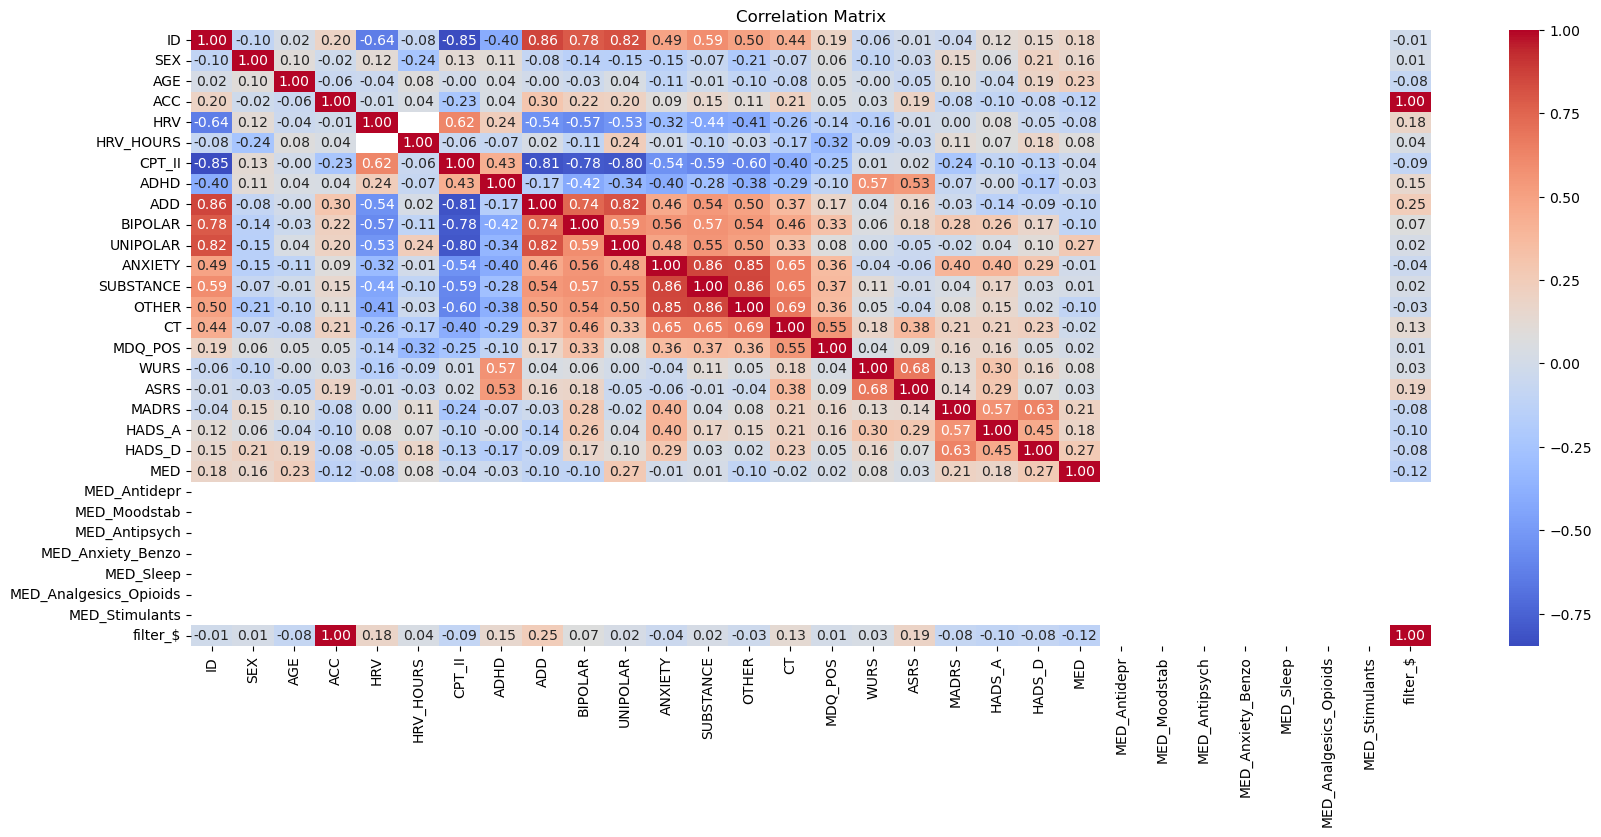

In [5]:
# Make a correlation matrix of the data

pred_df = pat_info_df.select_dtypes(include=['float64', 'int64'])

# Use seaborn for correlation matrix - display only half of the matrix
plt.figure(figsize=(20, 8))
sns.heatmap(pred_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')

### Preprocessing

In [6]:
# Prepare the data for KNN classification
# Select the features (X) and the target variable (y)
# Exclude objects
X = pat_info_df.drop(['ADHD', 'ID'], axis=1)
X = X.select_dtypes(exclude=['object'])
y = pat_info_df['ADHD']

# Fill null values with 0 
X.fillna(0, inplace=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train.shape

(107,)

### Building the model

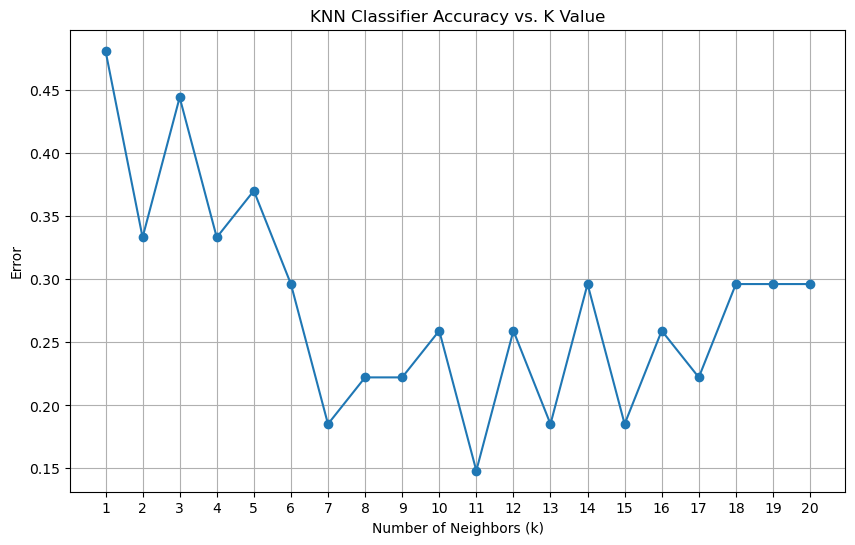

In [7]:
# Choosing k - the number of neighbors

# Create an elbow plot to find the optimal value of k
k_values = range(1, 21)
error_rate = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    error_rate.append(np.mean(y_pred != y_test))

# Plot the accuracy scores against k values
plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rate, marker='o')
plt.title('KNN Classifier Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error')
plt.xticks(k_values)
plt.grid()
plt.show()

Confusion Matrix:
 [[12  2]
 [ 2 11]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        14
           1       0.85      0.85      0.85        13

    accuracy                           0.85        27
   macro avg       0.85      0.85      0.85        27
weighted avg       0.85      0.85      0.85        27

Accuracy: 0.8518518518518519


Text(0.5, 1.0, 'Confusion Matrix (k = 11)')

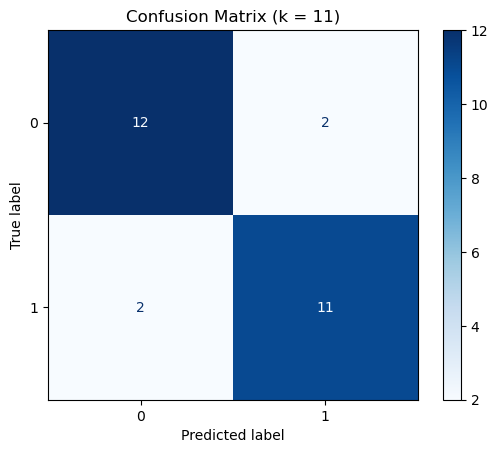

In [8]:
# Create a KNN classifier
knn = KNeighborsClassifier(n_neighbors=11)
# Fit the classifier to the training data
knn.fit(X_train, y_train)
# Make predictions on the test data
y_pred = knn.predict(X_test)
# Evaluate the classifier
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Plot the confusion matrix
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (k = 11)")

In [9]:
# Run 10-fold, 20-fold, and LOO cross-validation

# 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=11)
scores = cross_val_score(knn, X, y, cv=kf)
print("10-fold cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

# 20-fold cross-validation
kf = KFold(n_splits=20, shuffle=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=11)
scores = cross_val_score(knn, X, y, cv=kf)
print("20-fold cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

# Leave-One-Out cross-validation (LOO)
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
knn = KNeighborsClassifier(n_neighbors=11)
scores = cross_val_score(knn, X, y, cv=loo)
print("Leave-One-Out cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())


10-fold cross-validation scores: [0.78571429 0.78571429 0.92857143 0.78571429 0.53846154 0.84615385
 0.84615385 0.84615385 0.76923077 0.92307692]
Mean accuracy: 0.8054945054945055
20-fold cross-validation scores: [1.         0.57142857 0.85714286 0.71428571 0.85714286 0.85714286
 1.         0.57142857 0.71428571 0.57142857 0.71428571 1.
 0.71428571 0.85714286 1.         0.83333333 0.66666667 0.83333333
 0.83333333 1.        ]
Mean accuracy: 0.8083333333333332
Leave-One-Out cross-validation scores: [1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1.
 1. 1. 1. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0.
 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0.
 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.
 1. 1. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean accuracy: 0.7761194029850746
